In [1]:
from pycaret.datasets import get_data
import pickle
import math
import pandas as pd
from pycaret.regression import setup, create_model, tune_model, evaluate_model, finalize_model, predict_model, compare_models
import shap
from matplotlib import pyplot as plt
import random
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error as mae
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import norm
from scipy.stats import shapiro
pd.set_option('display.max_rows', None)

## Functions and Class for StratifiedGroupKFold:

In [2]:
def get_group_codes(data_df, group_by=None):
    """Encodes residue uniqueness as group codes for 'grouping'
    
    Signature: (df, [...]) --> df
    """
    if group_by is None:
        group_by = 'infor'
    code_dict = {}
    group_codes = []
    code = 0
    for i in data_df[group_by]:
        if i not in code_dict:
            code_dict[i] = code
            code += 1
        group_codes.append(code_dict[i]) 
    data_df['group_code'] = group_codes
    return data_df

def get_stratify_classes(data_df, stratify_on='Expt_pKa'):
    """Discretize our regression target for StratifiedGroupKFold
    
    Signature: (df, [...]) --> df
    """
    stratify_classes = []
    if stratify_on == 'd_pka':
        for _, r in data_df.iterrows():
            value = r[stratify_on] 
            if value < -2:
                stratify_classes.append(0)
            elif value >= -2 and value < -1:
                stratify_classes.append(1)
            elif value >= -1 and value < 0:
                stratify_classes.append(2)
            elif value >= 0 and value < 1:
                stratify_classes.append(3)
            elif value >= 1 and value < 2:
                stratify_classes.append(4)
            elif value >= 2:
                stratify_classes.append(5)
    elif stratify_on == 'Expt_pKa':
        for _, r in data_df.iterrows():
            value = r[stratify_on]
            if value < 3.0:
                stratify_classes.append(0)
            elif value >= 3.0 and value < 3.5:
                stratify_classes.append(1)
            elif value >= 3.5 and value < 4.0:
                stratify_classes.append(2)
            elif value >= 4.0 and value < 4.5:
                stratify_classes.append(3)
            elif value >= 4.5 and value < 5.0:
                stratify_classes.append(4)
            elif value >= 5.0 and value < 6.0:
                stratify_classes.append(5)
            elif value >= 6.0 and value < 7.0:
                stratify_classes.append(6)
            elif value >= 7.0 and value < 8.5:
                stratify_classes.append(7)
            elif value >= 8.5 and value < 10.5:
                stratify_classes.append(8)
            else:
                stratify_classes.append(9)
    elif stratify_on == 'ASP':
        m_pka = 3.7
        for _, r in data_df.iterrows():
            value = r['Expt_pKa']
            if value < 2.7:
                stratify_classes.append(0)
            elif value >= 2.7 and value < 3.7:
                stratify_classes.append(1)
            elif value >= 3.7 and value < 4.7:
                stratify_classes.append(2)
            elif value >= 4.7 and value < 5.7:
                stratify_classes.append(3)
            elif value >= 5.7 and value < 7.7:
                stratify_classes.append(4)
            elif value >= 7.7:
                stratify_classes.append(5)
    elif stratify_on == 'GLU':
        m_pka = 4.2
        for _, r in data_df.iterrows():
            value = r['Expt_pKa']
            if value < 2.2:
                stratify_classes.append(0)
            elif value >= 2.2 and value < 3.2:
                stratify_classes.append(1)
            elif value >= 3.2 and value < 4.2:
                stratify_classes.append(2)
            elif value >= 4.2 and value < 5.2:
                stratify_classes.append(3)
            elif value >= 5.2 and value < 6.2:
                stratify_classes.append(4)
            elif value >= 6.2 and value < 8.2:
                stratify_classes.append(5)
            elif value >= 8.2 and value < 10.2:
                stratify_classes.append(6)
            elif value >= 10.2:
                stratify_classes.append(7)
    elif stratify_on == 'HIS':
        m_pka = 6.5
        for _, r in data_df.iterrows():
            value = r['Expt_pKa']
            if value < 2.5:
                stratify_classes.append(0)
            elif value >= 2.5 and value < 4.5:
                stratify_classes.append(1)
            elif value >= 4.5 and value < 5.5:
                stratify_classes.append(2)
            elif value >= 5.5 and value < 6.5:
                stratify_classes.append(3)
            elif value >= 6.5 and value < 7.5:
                stratify_classes.append(4)
            elif value >= 7.5 and value < 8.5:
                stratify_classes.append(5)
            elif value >= 8.5 and value < 10.5:
                stratify_classes.append(6)
            elif value >= 10.5:
                stratify_classes.append(7)
    elif stratify_on == 'CYS':
        m_pka = 8.5
        for _, r in data_df.iterrows():
            value = r['Expt_pKa']
            if value < 5.5:
                stratify_classes.append(0)
            elif value >= 5.5 and value < 6.5:
                stratify_classes.append(1)
            elif value >= 6.5 and value < 7.5:
                stratify_classes.append(2)
            elif value >= 7.5 and value < 8.5:
                stratify_classes.append(3)
            elif value >= 8.5 and value < 9.5:
                stratify_classes.append(4)
            elif value >= 9.5 and value < 10.5:
                stratify_classes.append(5)
            elif value >= 10.5:
                stratify_classes.append(7)
    elif stratify_on == 'LYS':
        m_pka = 10.4
        for _, r in data_df.iterrows():
            value = r['Expt_pKa']
            if value < 4.4:
                stratify_classes.append(0)
            elif value >= 4.4 and value < 5.4:
                stratify_classes.append(1)
            elif value >= 5.4 and value < 6.4:
                stratify_classes.append(2)
            elif value >= 6.4 and value < 7.4:
                stratify_classes.append(3)
            elif value >= 7.4 and value < 9.4:
                stratify_classes.append(4)
            elif value >= 9.4 and value < 10.4:
                stratify_classes.append(5)
            elif value >= 10.4 and value < 11.4:
                stratify_classes.append(6)
            elif value >= 11.4 and value < 12.4:
                stratify_classes.append(7)
            elif value >= 12.4:
                stratify_classes.append(8)
    elif stratify_on == 'TYR':
        m_pka = 10.1
        for _, r in data_df.iterrows():
            value = r['Expt_pKa']
            if value < 10.1:
                stratify_classes.append(0)
            elif value >= 10.1 and value < 11.1:
                stratify_classes.append(1)
            elif value >= 11.1:
                stratify_classes.append(2)
    data_df['stratify_class'] = stratify_classes
    return data_df

class RegStratifiedGroupKFold:
    """StratifiedGroupKFold for regression
    Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html
    """
    def __init__(self, stratify_classes: list, n_splits=10, group_codes=None):
        self.stratify_classes = stratify_classes  # For 'stratify'; the 'y' argument in the sgkf.split() func
        self.group_codes = group_codes  # For 'group'; the 'groups' argument in the sgkf.split() func
        self.n_splits = n_splits
        if group_codes is not None:
            assert len(stratify_classes) == len(group_codes)

    def split(self, X, y, groups=None):
        sgkf = StratifiedGroupKFold(n_splits=self.n_splits)
        for i, (train_index, val_index) in enumerate(sgkf.split(X, self.stratify_classes, groups=self.group_codes)):
            yield train_index, val_index 
            
    def get_n_splits(self, X, y, groups=None):
        return self.n_splits

In [3]:
def add_titr_features(data_df):
    """Add titratable residue related features
    
    Signature: df --> df
    """
    for index, row in data_df.iterrows():
        resnm = row['Res_Name']
        if resnm == 'ASP':
            dpka = round(row['Expt_pKa'] - 3.7, 1)
            data_df.loc[index, 'd_pka'] = dpka
            data_df.loc[index, 'model_pka'] = float(3.7)
            data_df.loc[index, 'n_sc_C'] = 2
            data_df.loc[index, 'charge'] = -1
#             data_df.loc[index, 'charge_change'] = 'neu_to_neg'
        elif resnm == 'GLU':
            dpka = round(row['Expt_pKa'] - 4.2, 1)
            data_df.loc[index, 'd_pka'] = dpka
            data_df.loc[index, 'model_pka'] = float(4.2)
            data_df.loc[index, 'n_sc_C'] = 3
            data_df.loc[index, 'charge'] = -1
#             data_df.loc[index, 'charge_change'] = 'neu_to_neg'
        elif resnm == 'HIS':
            dpka = round(row['Expt_pKa'] - 6.5, 1)
            data_df.loc[index, 'd_pka'] = dpka
            data_df.loc[index, 'model_pka'] = float(6.5)
            data_df.loc[index, 'n_sc_C'] = 2
            data_df.loc[index, 'charge'] = 0
#             data_df.loc[index, 'charge_change'] = 'pos_to_neu'
        elif resnm == 'CYS':
            dpka = round(row['Expt_pKa'] - 8.5, 1)
            data_df.loc[index, 'd_pka'] = dpka
            data_df.loc[index, 'model_pka'] = float(8.5)
            data_df.loc[index, 'n_sc_C'] = 1
            data_df.loc[index, 'charge'] = 0
#             data_df.loc[index, 'charge_change'] = 'neu_to_neg'
        elif resnm == 'LYS':
            dpka = round(row['Expt_pKa'] - 10.4, 1)
            data_df.loc[index, 'd_pka'] = dpka
            data_df.loc[index, 'model_pka'] = float(10.4)
            data_df.loc[index, 'n_sc_C'] = 4
            data_df.loc[index, 'charge'] = 1
#             data_df.loc[index, 'charge_change'] = 'pos_to_neu'
        elif resnm == 'TYR':
            dpka = round(row['Expt_pKa'] - 9.5, 1)
            data_df.loc[index, 'd_pka'] = dpka
            data_df.loc[index, 'model_pka'] = float(9.5)
            data_df.loc[index, 'n_sc_C'] = 2
            data_df.loc[index, 'charge'] = 0
#             data_df.loc[index, 'charge_change'] = 'neu_to_neg'
    return data_df

In [4]:
resnm_dict = {'ASP': 'D', 'GLU': 'E', 'HIS': 'H', 'CYS': 'C', 'LYS': 'K', 'TYR': 'Y'}
respk_dict = {'ASP': 3.7, 'GLU': 4.2, 'HIS': 6.5, 'CYS': 8.5, 'LYS': 10.4, 'TYR': 10.1}
color_dict = {'ASP': 'red', 'GLU': 'darkorange', 'HIS': 'gold', 'CYS': 'green', 'LYS': 'dodgerblue', 'TYR': 'blueviolet'}

In [5]:
### info is defined as 'PDBID-Chain-resid'
def clean_dataset(df):
    df_new = df[df['info'] != '1UCQ-A-85']
    df_new = df_new[df_new['info'] != '1C5Q-A-102']
    df_new = df_new[df_new['info'] != '3VZO-A-172']
    df_new = df_new[df_new['info'] != '2V8N-A-352']
    df_new = df_new[df_new['info'] != '2DUP-A-149']
    df_new = df_new[df_new['PDB_ID'] != '2RKS']
    df_new.loc[df_new["info"] == "4PTI-A-21", "Expt_pKa"] = 11.0
    df_new.loc[df_new["info"] == "1BPI-A-21", "Expt_pKa"] = 10.0
    df_new.loc[df_new["info"] == "1XNB-A-172", "Expt_pKa"] = 6.7
    df_new.loc[df_new["info"] == "1A42-A-64", "Expt_pKa"] = 6
    df_new.loc[df_new["info"] == "1BPI-A-23", "Expt_pKa"] = 11
    df_new.loc[df_new["info"] == "2KT2-A-11", "Expt_pKa"] = 6.2
    df_new.loc[df_new["info"] == "6K5W-A-18", "Expt_pKa"] = 6.8
    df_new.loc[df_new["info"] == "1AXT-H-93", "Expt_pKa"] = 5.5
    df_new.loc[df_new['PDB_ID'] == '4I3V', 'Chain'] = 'A'
    df_new.loc[df_new['PDB_ID'] == '2AAZ', 'Chain'] = 'A'
    df_new.loc[df_new['PDB_ID'] == '4QBB', 'Chain'] = 'A'
    df_new.loc[df_new['PDB_ID'] == '3SZ9', 'Chain'] = 'A'
    df_new.loc[df_new['PDB_ID'] == '5DU9', 'Chain'] = 'A'
    df_new.loc[df_new['PDB_ID'] == '4V37', 'Chain'] = 'A'
    df_new = df_new[df_new['PDB_ID'] != '3VZM']
    df_new = df_new[df_new['PDB_ID'] != '3VZN']
    df_new = df_new[df_new['PDB_ID'] != '3VZO']
    return df_new

## Data splitting

In [12]:
def get_stratified_grouped_train_test_dfs(data_df, stratify_on=None,
                                          group_by=None, test_ratio=0.1,
                                          random_state=0, debug=True,
                                         ):
    """Get train and test dfs based on grouping and stratifying
    
    Signature: (df, [...]) --> df
    stratify_on: which column to stratify against
    group_by: which column to group by
    test_ratio: ratio for splitting into the test set as to group_by
    random_state: for sampling group codes
    debug: whether to check the classes
    """
    if stratify_on is None:
        stratify_on = 'Expt_pKa'
    if group_by is None:
        group_by = 'infor'
    data_df = get_stratify_classes(data_df, stratify_on=stratify_on)  # in 'stratify_class' column
    data_df = get_group_codes(data_df, group_by='infor')  # defined as Uniprot_ID+uni_resid
    
    test_group_codes = []
    stratify_classes = data_df.stratify_class.unique()
    n = 0
    for stratify_class in sorted(stratify_classes):
        class_df = data_df[data_df.stratify_class == stratify_class]
        group_codes_in_class = class_df.group_code.unique()
        n_groups_in_class = len(group_codes_in_class)
        n_test_in_class = int(round(n_groups_in_class * test_ratio, 0))
        if debug:
            if n == 0:
                print("stratify_class n_groups_in_class n_test_in_class")
            print(stratify_class, n_groups_in_class, n_test_in_class)
        random.seed(random_state)
        group_codes_in_test = random.sample(list(group_codes_in_class),
                                            n_test_in_class,
                                           )
        test_group_codes += group_codes_in_test
        n += 1
    test_df = data_df[data_df.group_code.isin(test_group_codes)]
    
    train_df = data_df.drop(test_df.index)
    
    # shuffle
    train_df = train_df.sample(frac=1, random_state=random_state).reset_index(drop = True)
    test_df = test_df.sample(frac=1, random_state=random_state).reset_index(drop = True)
    
    return train_df, test_df

In [7]:
aspbin = [0, 2.7, 3.7, 4.7, 5.7, 7.7, 14]
glubin = [0, 2.2, 3.2, 4.2, 5.2, 6.2, 8.2, 10.2, 14]
hisbin = [0, 2.5, 4.5, 5.5, 6.5, 7.5, 8.5, 10.5, 14]
cysbin = [0, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 14]
lysbin = [0, 4.4, 5.4, 6.4, 7.4, 9.4, 10.4, 11.4, 12.4, 14]
tyrbin = [0, 10.1, 11.1, 14]

In [8]:
df_all = pd.read_csv('pkad3.dat')   ### can be downloaded from https://database.computchem.org/pkad-3
df_all = clean_dataset(df_all)

In [13]:
## train-val split
df = df_tv.copy()
### split based on res_type
i = 0 ### n_expt
df_asp = df[df['Res_Name'] == 'ASP']
df_glu = df[df['Res_Name'] == 'GLU']
df_his = df[df['Res_Name'] == 'HIS']
df_cys = df[df['Res_Name'] == 'CYS']
df_lys = df[df['Res_Name'] == 'LYS']
df_tyr = df[df['Res_Name'] == 'TYR']
for n_fold in range(10):
    train_asp, val_asp = get_stratified_grouped_train_test_dfs(df_asp, random_state=n_fold, stratify_on = 'ASP')
    train_glu, val_glu = get_stratified_grouped_train_test_dfs(df_glu, random_state=n_fold, stratify_on = 'GLU')
    train_his, val_his = get_stratified_grouped_train_test_dfs(df_his, random_state=n_fold, stratify_on = 'HIS')
    train_cys, val_cys = get_stratified_grouped_train_test_dfs(df_cys, random_state=n_fold, stratify_on = 'CYS')
    train_lys, val_lys = get_stratified_grouped_train_test_dfs(df_lys, random_state=n_fold, stratify_on = 'LYS')
    train_tyr, val_tyr = get_stratified_grouped_train_test_dfs(df_tyr, random_state=n_fold, stratify_on = 'TYR')
    train_df = pd.concat([train_asp, train_glu, train_his, train_cys, train_lys, train_tyr], ignore_index = True)
    val_df = pd.concat([val_asp, val_glu, val_his, val_cys, val_lys, val_tyr], ignore_index = True)
    train_df.drop(columns = ['stratify_class', 'group_code'])
    val_df.drop(columns = ['stratify_class', 'group_code'])
    train_df.to_csv(f'/home/mings/his_pka/split_restype_v3/expt{i}f{n_fold}_train_10.csv', index = False)
    val_df.to_csv(f'/home/mings/his_pka/split_restype_v3/expt{i}f{n_fold}_validation_10.csv', index = False)
print(len(train_df), len(val_df))
print('===============================================')

stratify_class n_groups_in_class n_test_in_class
0 40 4
1 93 9
2 69 7
3 9 1
4 46 5
5 35 4
stratify_class n_groups_in_class n_test_in_class
0 1 0
1 17 2
2 138 14
3 101 10
4 13 1
5 38 4
6 11 1
7 1 0
stratify_class n_groups_in_class n_test_in_class
1 8 1
2 16 2
3 50 5
4 47 5
5 21 2
6 6 1
stratify_class n_groups_in_class n_test_in_class
0 18 2
1 14 1
2 36 4
3 94 9
4 95 10
5 51 5
7 9 1
stratify_class n_groups_in_class n_test_in_class
1 1 0
2 8 1
3 11 1
4 15 2
5 18 2
6 49 5
7 4 0
stratify_class n_groups_in_class n_test_in_class
0 11 1
1 18 2
2 7 1
stratify_class n_groups_in_class n_test_in_class
0 40 4
1 93 9
2 69 7
3 9 1
4 46 5
5 35 4
stratify_class n_groups_in_class n_test_in_class
0 1 0
1 17 2
2 138 14
3 101 10
4 13 1
5 38 4
6 11 1
7 1 0
stratify_class n_groups_in_class n_test_in_class
1 8 1
2 16 2
3 50 5
4 47 5
5 21 2
6 6 1
stratify_class n_groups_in_class n_test_in_class
0 18 2
1 14 1
2 36 4
3 94 9
4 95 10
5 51 5
7 9 1
stratify_class n_groups_in_class n_test_in_class
1 1 0
2 8 1
3 11 1


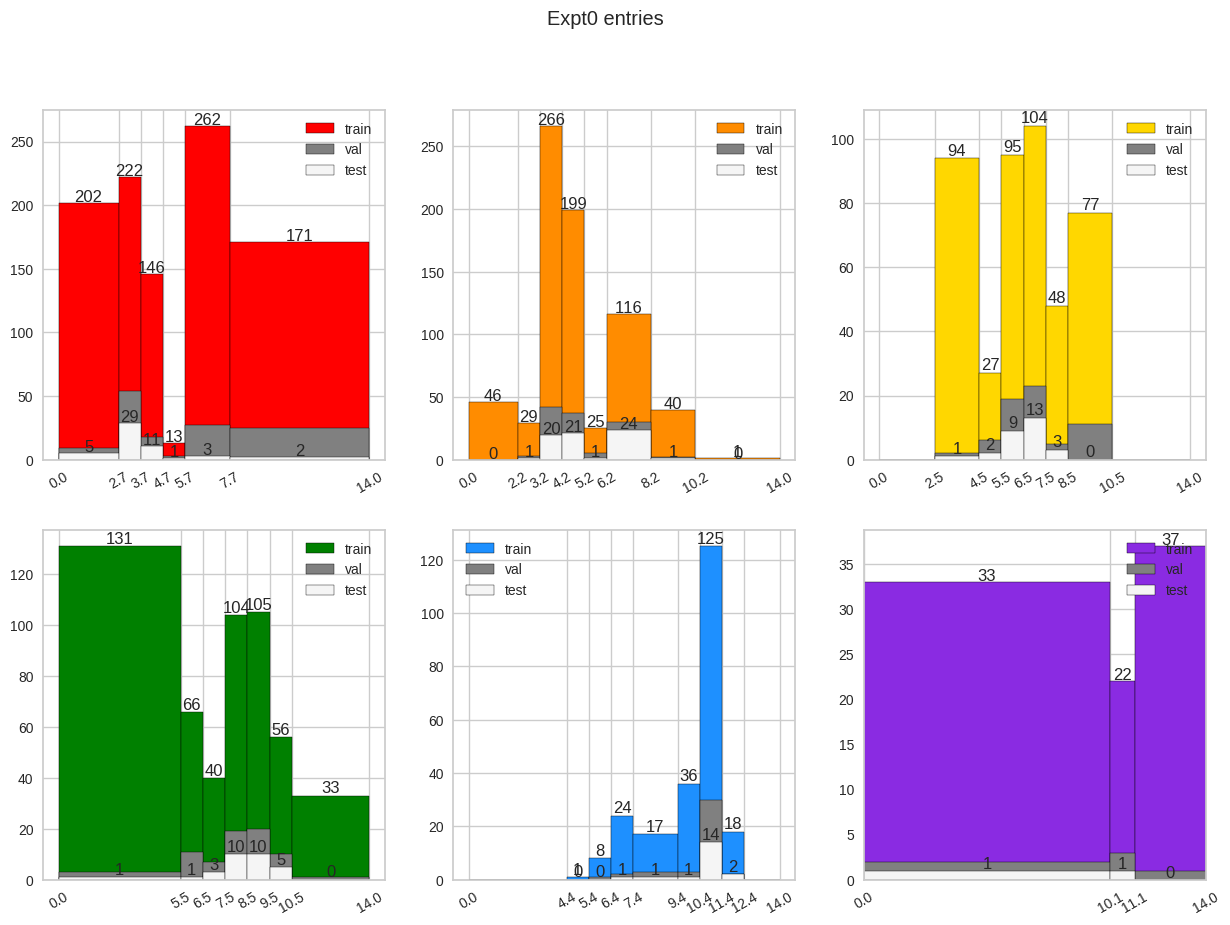

In [14]:
n_expt = 0
df_train = pd.read_csv(f'expt{n_expt}f0_train.csv')
df_train['split'] = 'train'
df_val = pd.read_csv(f'expt{n_expt}f0_validation.csv')
df_val['split'] = 'val'
df_test = pd.read_csv(f'expt{n_expt}_test.csv')
df_test['split'] = 'test'
df_vt = pd.concat([df_val, df_test], ignore_index = True)
df_tvt = pd.concat([df_train, df_val, df_test], ignore_index = True)
fig, [(ax0, ax1, ax2), (ax3, ax4, ax5)] = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 10)) 
### ASP
respk = respk_dict['ASP']
bins = aspbin
n, bins, patches = ax0.hist(df_tvt[df_tvt['Res_Name'] == 'ASP']['Expt_pKa'], bins=bins)
n1, bins1, patches1 = ax0.hist(df_vt[df_vt['Res_Name'] == 'ASP']['Expt_pKa'], bins=bins)
n2, bins2, patches2 = ax0.hist(df_test[df_test['Res_Name'] == 'ASP']['Expt_pKa'], bins=bins)
width = np.diff(bins)
center = (bins[:-1] + bins[1:]) / 2
ax0.bar(center, n, align='center', width=width, color = color_dict['ASP'], label = 'train', edgecolor = 'black')
ax0.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
ax0.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
ax0.set_xticks(bins)
ax0.tick_params(axis='x', labelrotation=30)
for i in range(len(bins) - 1):
    if n[i] > 0:
        ax0.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
        ax0.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
ax0.legend()
### GLU
respk = respk_dict['GLU']
bins = glubin
n, bins, patches = ax1.hist(df_tvt[df_tvt['Res_Name'] == 'GLU']['Expt_pKa'], bins=bins)
n1, bins1, patches1 = ax1.hist(df_vt[df_vt['Res_Name'] == 'GLU']['Expt_pKa'], bins=bins)
n2, bins2, patches2 = ax1.hist(df_test[df_test['Res_Name'] == 'GLU']['Expt_pKa'], bins=bins)
width = np.diff(bins)
center = (bins[:-1] + bins[1:]) / 2
ax1.bar(center, n, align='center', width=width, color = color_dict['GLU'], label = 'train', edgecolor = 'black')
ax1.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
ax1.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
ax1.set_xticks(bins)
ax1.tick_params(axis='x', labelrotation=30)
for i in range(len(bins) - 1):
    if n[i] > 0:
        ax1.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
        ax1.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
ax1.legend()
### HIS
respk = respk_dict['HIS']
bins = hisbin
n, bins, patches = ax2.hist(df_tvt[df_tvt['Res_Name'] == 'HIS']['Expt_pKa'], bins=bins)
n1, bins1, patches1 = ax2.hist(df_vt[df_vt['Res_Name'] == 'HIS']['Expt_pKa'], bins=bins)
n2, bins2, patches2 = ax2.hist(df_test[df_test['Res_Name'] == 'HIS']['Expt_pKa'], bins=bins)
width = np.diff(bins)
center = (bins[:-1] + bins[1:]) / 2
ax2.bar(center, n, align='center', width=width, color = color_dict['HIS'], label = 'train', edgecolor = 'black')
ax2.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
ax2.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
ax2.set_xticks(bins)
ax2.tick_params(axis='x', labelrotation=30)
for i in range(len(bins) - 1):
    if n[i] > 0:
        ax2.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
        ax2.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
ax2.legend()
### CYS
respk = respk_dict['CYS']
bins = cysbin
n, bins, patches = ax3.hist(df_tvt[df_tvt['Res_Name'] == 'CYS']['Expt_pKa'], bins=bins)
n1, bins1, patches1 = ax3.hist(df_vt[df_vt['Res_Name'] == 'CYS']['Expt_pKa'], bins=bins)
n2, bins2, patches2 = ax3.hist(df_test[df_test['Res_Name'] == 'CYS']['Expt_pKa'], bins=bins)
width = np.diff(bins)
center = (bins[:-1] + bins[1:]) / 2
ax3.bar(center, n, align='center', width=width, color = color_dict['CYS'], label = 'train', edgecolor = 'black')
ax3.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
ax3.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
ax3.set_xticks(bins)
ax3.tick_params(axis='x', labelrotation=30)
for i in range(len(bins) - 1):
    if n[i] > 0:
        ax3.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
        ax3.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
ax3.legend()
### LYS
respk = respk_dict['LYS']
bins = lysbin
n, bins, patches = ax4.hist(df_tvt[df_tvt['Res_Name'] == 'LYS']['Expt_pKa'], bins=bins)
n1, bins1, patches1 = ax4.hist(df_vt[df_vt['Res_Name'] == 'LYS']['Expt_pKa'], bins=bins)
n2, bins2, patches2 = ax4.hist(df_test[df_test['Res_Name'] == 'LYS']['Expt_pKa'], bins=bins)
width = np.diff(bins)
center = (bins[:-1] + bins[1:]) / 2
ax4.bar(center, n, align='center', width=width, color = color_dict['LYS'], label = 'train', edgecolor = 'black')
ax4.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
ax4.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
ax4.set_xticks(bins)
ax4.tick_params(axis='x', labelrotation=30)
for i in range(len(bins) - 1):
    if n[i] > 0:
        ax4.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
        ax4.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
ax4.legend()
### TYR
respk = respk_dict['TYR']
bins = tyrbin
n, bins, patches = ax5.hist(df_tvt[df_tvt['Res_Name'] == 'TYR']['Expt_pKa'], bins=bins)
n1, bins1, patches1 = ax5.hist(df_vt[df_vt['Res_Name'] == 'TYR']['Expt_pKa'], bins=bins)
n2, bins2, patches2 = ax5.hist(df_test[df_test['Res_Name'] == 'TYR']['Expt_pKa'], bins=bins)
width = np.diff(bins)
center = (bins[:-1] + bins[1:]) / 2
ax5.bar(center, n, align='center', width=width, color = color_dict['TYR'], label = 'train', edgecolor = 'black')
ax5.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
ax5.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
ax5.set_xticks(bins)
ax5.tick_params(axis='x', labelrotation=30)
for i in range(len(bins) - 1):
    if n[i] > 0:
        ax5.text((bins[i] + bins[i + 1])/2, n[i] + 0.2, str(int(n[i])), ha='center')
        ax5.text((bins2[i] + bins2[i + 1])/2, n2[i] + 0.2, str(int(n2[i])), ha='center')
ax5.legend()
fig.suptitle(f'Expt{n_expt} entries')
plt.xlim([0, 14])
plt.show()
print('======================================================================')

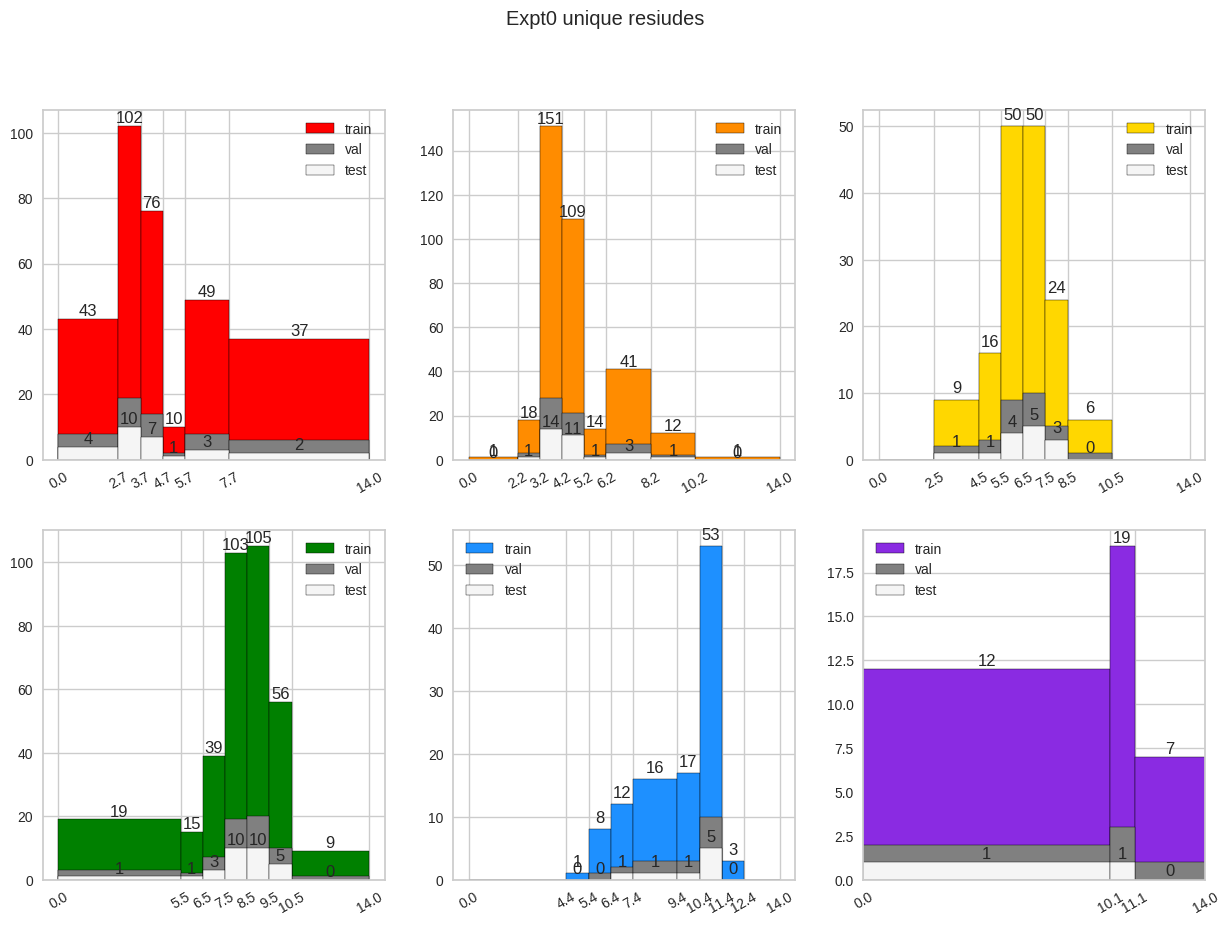

In [15]:
for n_expt in range(1):
    df_train = pd.read_csv(f'/home/mings/his_pka/split_restype_v3/expt{n_expt}f0_train_10.csv')
    df_train['split'] = 'train'
    df_train = df_train.drop_duplicates(subset = ['infor'])
    df_val = pd.read_csv(f'/home/mings/his_pka/split_restype_v3/expt{n_expt}f0_validation_10.csv')
    df_val['split'] = 'val'
    df_val = df_val.drop_duplicates(subset = ['infor'])
    df_test = pd.read_csv(f'/home/mings/his_pka/split_restype_v3/expt{n_expt}_test.csv')
    df_test['split'] = 'test'
    df_test = df_test.drop_duplicates(subset = ['infor'])
    df_vt = pd.concat([df_val, df_test], ignore_index = True)
    df_tvt = pd.concat([df_train, df_val, df_test], ignore_index = True)
    fig, [(ax0, ax1, ax2), (ax3, ax4, ax5)] = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 10)) 
    ### ASP
    respk = respk_dict['ASP']
    bins = aspbin
    n, bins, patches = ax0.hist(df_tvt[df_tvt['Res_Name'] == 'ASP']['Expt_pKa'], bins=bins)
    n1, bins1, patches1 = ax0.hist(df_vt[df_vt['Res_Name'] == 'ASP']['Expt_pKa'], bins=bins)
    n2, bins2, patches2 = ax0.hist(df_test[df_test['Res_Name'] == 'ASP']['Expt_pKa'], bins=bins)
    width = np.diff(bins)
    center = (bins[:-1] + bins[1:]) / 2
    ax0.bar(center, n, align='center', width=width, color = color_dict['ASP'], label = 'train', edgecolor = 'black')
    ax0.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
    ax0.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
    ax0.set_xticks(bins)
    ax0.tick_params(axis='x', labelrotation=30)
    for i in range(len(bins) - 1):
        if n[i] > 0:
            ax0.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
            ax0.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
    ax0.legend()
    ### GLU
    respk = respk_dict['GLU']
    bins = glubin
    n, bins, patches = ax1.hist(df_tvt[df_tvt['Res_Name'] == 'GLU']['Expt_pKa'], bins=bins)
    n1, bins1, patches1 = ax1.hist(df_vt[df_vt['Res_Name'] == 'GLU']['Expt_pKa'], bins=bins)
    n2, bins2, patches2 = ax1.hist(df_test[df_test['Res_Name'] == 'GLU']['Expt_pKa'], bins=bins)
    width = np.diff(bins)
    center = (bins[:-1] + bins[1:]) / 2
    ax1.bar(center, n, align='center', width=width, color = color_dict['GLU'], label = 'train', edgecolor = 'black')
    ax1.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
    ax1.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
    ax1.set_xticks(bins)
    ax1.tick_params(axis='x', labelrotation=30)
    for i in range(len(bins) - 1):
        if n[i] > 0:
            ax1.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
            ax1.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
    ax1.legend()
    ### HIS
    respk = respk_dict['HIS']
    bins = hisbin
    n, bins, patches = ax2.hist(df_tvt[df_tvt['Res_Name'] == 'HIS']['Expt_pKa'], bins=bins)
    n1, bins1, patches1 = ax2.hist(df_vt[df_vt['Res_Name'] == 'HIS']['Expt_pKa'], bins=bins)
    n2, bins2, patches2 = ax2.hist(df_test[df_test['Res_Name'] == 'HIS']['Expt_pKa'], bins=bins)
    width = np.diff(bins)
    center = (bins[:-1] + bins[1:]) / 2
    ax2.bar(center, n, align='center', width=width, color = color_dict['HIS'], label = 'train', edgecolor = 'black')
    ax2.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
    ax2.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
    ax2.set_xticks(bins)
    ax2.tick_params(axis='x', labelrotation=30)
    for i in range(len(bins) - 1):
        if n[i] > 0:
            ax2.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
            ax2.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
    ax2.legend()
    ### CYS
    respk = respk_dict['CYS']
    bins = cysbin
    n, bins, patches = ax3.hist(df_tvt[df_tvt['Res_Name'] == 'CYS']['Expt_pKa'], bins=bins)
    n1, bins1, patches1 = ax3.hist(df_vt[df_vt['Res_Name'] == 'CYS']['Expt_pKa'], bins=bins)
    n2, bins2, patches2 = ax3.hist(df_test[df_test['Res_Name'] == 'CYS']['Expt_pKa'], bins=bins)
    width = np.diff(bins)
    center = (bins[:-1] + bins[1:]) / 2
    ax3.bar(center, n, align='center', width=width, color = color_dict['CYS'], label = 'train', edgecolor = 'black')
    ax3.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
    ax3.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
    ax3.set_xticks(bins)
    ax3.tick_params(axis='x', labelrotation=30)
    for i in range(len(bins) - 1):
        if n[i] > 0:
            ax3.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
            ax3.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
    ax3.legend()
    ### LYS
    respk = respk_dict['LYS']
    bins = lysbin
    n, bins, patches = ax4.hist(df_tvt[df_tvt['Res_Name'] == 'LYS']['Expt_pKa'], bins=bins)
    n1, bins1, patches1 = ax4.hist(df_vt[df_vt['Res_Name'] == 'LYS']['Expt_pKa'], bins=bins)
    n2, bins2, patches2 = ax4.hist(df_test[df_test['Res_Name'] == 'LYS']['Expt_pKa'], bins=bins)
    width = np.diff(bins)
    center = (bins[:-1] + bins[1:]) / 2
    ax4.bar(center, n, align='center', width=width, color = color_dict['LYS'], label = 'train', edgecolor = 'black')
    ax4.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
    ax4.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
    ax4.set_xticks(bins)
    ax4.tick_params(axis='x', labelrotation=30)
    for i in range(len(bins) - 1):
        if n[i] > 0:
            ax4.text((bins[i] + bins[i + 1])/2, n[i] + 1, str(int(n[i])), ha='center')
            ax4.text((bins2[i] + bins2[i + 1])/2, n2[i] + 1, str(int(n2[i])), ha='center')
    ax4.legend()
    ### TYR
    respk = respk_dict['TYR']
    bins = tyrbin
    n, bins, patches = ax5.hist(df_tvt[df_tvt['Res_Name'] == 'TYR']['Expt_pKa'], bins=bins)
    n1, bins1, patches1 = ax5.hist(df_vt[df_vt['Res_Name'] == 'TYR']['Expt_pKa'], bins=bins)
    n2, bins2, patches2 = ax5.hist(df_test[df_test['Res_Name'] == 'TYR']['Expt_pKa'], bins=bins)
    width = np.diff(bins)
    center = (bins[:-1] + bins[1:]) / 2
    ax5.bar(center, n, align='center', width=width, color = color_dict['TYR'], label = 'train', edgecolor = 'black')
    ax5.bar(center, n1, align='center', width=width, color = 'grey', label = 'val', edgecolor = 'black')
    ax5.bar(center, n2, align='center', width=width, color = 'whitesmoke', label = 'test', edgecolor = 'black')
    ax5.set_xticks(bins)
    ax5.tick_params(axis='x', labelrotation=30)
    for i in range(len(bins) - 1):
        if n[i] > 0:
            ax5.text((bins[i] + bins[i + 1])/2, n[i] + 0.2, str(int(n[i])), ha='center')
            ax5.text((bins2[i] + bins2[i + 1])/2, n2[i] + 0.2, str(int(n2[i])), ha='center')
    ax5.legend()
    fig.suptitle(f'Expt{n_expt} unique resiudes')
    plt.xlim([0, 14])
    plt.show()
    print('======================================================================')